# Ejemplo ANN - Loan Approval Prediction

Este notebook muestra una linea base para clasificacion binaria con una red neuronal artificial (ANN) usando TensorFlow/Keras.

Dataset: Loan Approval Prediction Dataset (Kaggle).

## 1) Importaciones

In [10]:
!pip install pandas

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

## 2) Cargar dataset

In [12]:
file_path = 'loan_approval_dataset.csv'
df = pd.read_csv(file_path)

# Limpieza basica de nombres y texto
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print('Shape:', df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3) Exploracion rapida

In [13]:
print(df.info())
print('\nDistribucion loan_status:')
print(df['loan_status'].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None

Distribucion loan_status

## 4) Preparar X e y

In [14]:
target_col = 'loan_status'
drop_cols = ['loan_id', target_col]

X = df.drop(columns=drop_cols)
y = df[target_col].map({'Approved': 1, 'Rejected': 0})

if y.isna().any():
    raise ValueError('Se encontraron etiquetas no reconocidas en loan_status')

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Categoricas:', categorical_cols)
print('Numericas :', numeric_cols)
print('X shape   :', X.shape)

Categoricas: ['education', 'self_employed']
Numericas : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
X shape   : (4269, 11)


## 5) Split + Preprocesamiento

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Convertir a array denso para Keras
X_train_prep = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep
X_test_prep = X_test_prep.toarray() if hasattr(X_test_prep, 'toarray') else X_test_prep

print('X_train_prep:', X_train_prep.shape)
print('X_test_prep :', X_test_prep.shape)

X_train_prep: (3415, 13)
X_test_prep : (854, 13)


## 6) Construir ANN

In [16]:
input_dim = X_train_prep.shape[1]

model = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 32)                448       
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 16)                528       
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


## 7) Entrenamiento

In [17]:
history = model.fit(
    X_train_prep, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=2
)

print('Entrenamiento completado. Epocas ejecutadas:', len(history.history['loss']))

Epoch 1/100
86/86 - 1s - loss: 0.5764 - accuracy: 0.7057 - val_loss: 0.4547 - val_accuracy: 0.8097 - 889ms/epoch - 10ms/step
Epoch 2/100
86/86 - 0s - loss: 0.3800 - accuracy: 0.8474 - val_loss: 0.2849 - val_accuracy: 0.9004 - 351ms/epoch - 4ms/step
Epoch 3/100
86/86 - 0s - loss: 0.2751 - accuracy: 0.8957 - val_loss: 0.2437 - val_accuracy: 0.9136 - 352ms/epoch - 4ms/step
Epoch 4/100
86/86 - 0s - loss: 0.2496 - accuracy: 0.9034 - val_loss: 0.2384 - val_accuracy: 0.9239 - 314ms/epoch - 4ms/step
Epoch 5/100
86/86 - 0s - loss: 0.2311 - accuracy: 0.9023 - val_loss: 0.2257 - val_accuracy: 0.9239 - 323ms/epoch - 4ms/step
Epoch 6/100
86/86 - 0s - loss: 0.2199 - accuracy: 0.9096 - val_loss: 0.2286 - val_accuracy: 0.9283 - 335ms/epoch - 4ms/step
Epoch 7/100
86/86 - 0s - loss: 0.2078 - accuracy: 0.9220 - val_loss: 0.2167 - val_accuracy: 0.9253 - 321ms/epoch - 4ms/step
Epoch 8/100
86/86 - 0s - loss: 0.1932 - accuracy: 0.9242 - val_loss: 0.2166 - val_accuracy: 0.9312 - 350ms/epoch - 4ms/step
Epoch 9

## 8) Evaluacion

In [18]:
y_proba = model.predict(X_test_prep, verbose=0).ravel()
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print('Accuracy test:', round(acc, 4))
print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Accuracy test: 0.9836

Reporte de clasificacion:
              precision    recall  f1-score   support

    Rejected       0.99      0.97      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## 9) Graficas de evaluacion

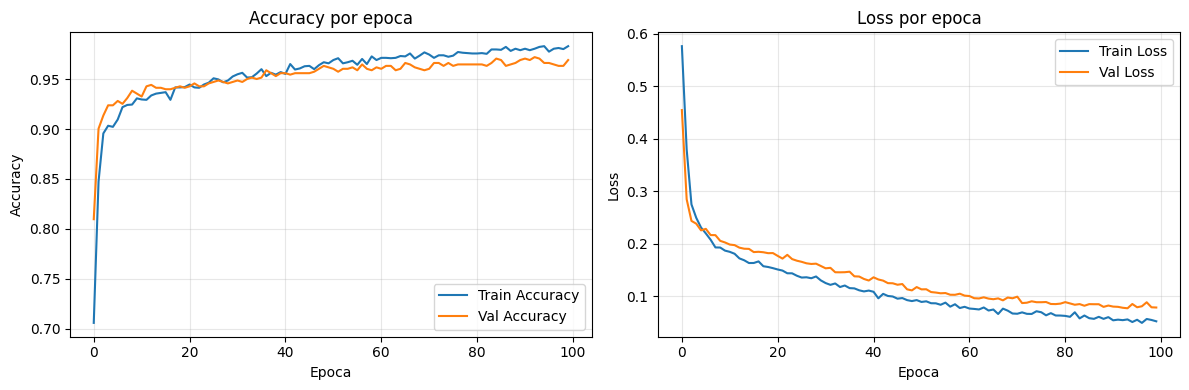

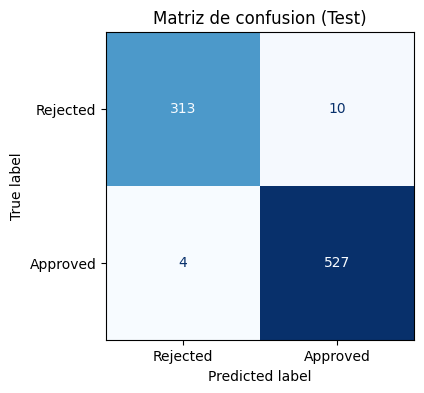

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusion (Test)')
plt.show()

## 10) Reto para actividad

1. Cambia la arquitectura (capas, neuronas, dropout) y compara resultados.
2. Ajusta el umbral de clasificacion (por ejemplo 0.4, 0.6) y analiza precision/recall.
3. Evalua si hay overfitting con las curvas de entrenamiento.
4. Propone una version mejorada del pipeline y justifica tus decisiones.